# view recommendation

From a homogeneous BRDF sphere setup, a view is a pixel taken from the rendered image.

In [1]:
import time
# SYNTHETIC SCENE SETUP
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image
from ivt.sampling import sample_sphere


from matplotlib import pyplot as plt
import torch
import numpy as np
from tqdm.notebook import tqdm

scene = Scene()

# material
SPECULAR=0.04
scene.set('mat', MicrofacetBRDF(0.3, SPECULAR, 0.3))
scene.set('mesh1', Mesh.from_file("assets/meshes/sphere.obj", 'mat')) # surface to reconstruct
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('collocated', {'intensity':1}))
# scene.set('cam1', PerspectiveCamera.from_lookat(fov=40, origin=(1,0.5,0), target=(0,0,0), up=(0,1,0))) # camera

# randomly generate cameras
num_sensors = 1
fov = 40
radius = 1
target = (0,0,0)
up = (0,1,0)
for i, origin in enumerate(sample_sphere(num_sensors, radius, 'fibonacci')):
    scene.set(f'sensor {i}', PerspectiveCamera.from_lookat(fov, origin, target, up))

# render target images
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 16,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't update changes in spp, workaround here to render a higher spp target image
renders = torch.stack([renderer(scene, sensor_ids=range(num_sensors)) for _ in tqdm(range(100))])

  0%|          | 0/100 [00:00<?, ?it/s]

In [26]:
!python --version

Python 3.8.16


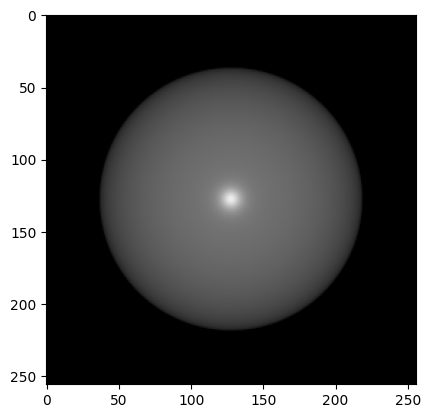

In [2]:
I_t = renders.mean(axis=0)
stddev = renders.std(axis=0)

# Visualize a target Image
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
showimg(I_t)

In [3]:
target = I_t[0,128,0:129,1]
target_dev = stddev[0,128,0:129,1]

In [4]:
# render images on D&R, fix S parameter combinations
import math
from math import sqrt, pi

def image(x):
    xo = x.cuda()
    scene['mat']['d'] = xo[0]
    scene['mat']['s'] = xo[1]
    scene['mat']['r'] = xo[2]
    img = renderer(scene)
    I = img[0,128,0:129,1]
    return I
    
def log_p_hat(x, observed_pixels):
    I = image(x)
    sigma = torch.tensor(0.05)
    lpdf = (I - target).pow(2.0) / (2.0 * sigma.pow(2.0)) + (sigma*sqrt(2*pi)).log()
    return lpdf[..., observed_pixels].sum(axis=-1).item()
    
def importance_resample(observed_pixels, sample_budget = 1000, source_sampler='independent', rejection_sampler='independent'):
    # generate source samples
    if source_sampler == 'sobol':
        sobol_engine = torch.quasirandom.SobolEngine(dimension=2, scramble=True, seed=None)
        samples = sobol_engine.draw(sample_budget)
    elif source_sampler == 'independent':
        samples = torch.rand((sample_budget, 2))
    samples = torch.vstack((samples[:,0], torch.full((sample_budget,), 0.04), samples[:,1])).transpose(1, 0)
    # evaluate target function
    Us = [log_p_hat(x, observed_pixels) for x in tqdm(samples)]
    # generate rejection test samples
    if rejection_sampler == 'golden':
        g = (math.sqrt(5)-1)/2
        rej = torch.frac(torch.tensor([g*(i+1) for i in range(sample_budget)]))
    elif rejection_sampler == 'independent':
        rej = torch.rand(sample_budget)
    minU = min(Us)
    final = [samples[i] for i in range(sample_budget) if rej[i] < math.exp(minU - Us[i])]
    print("accept rate:", len(final) / sample_budget)
    return torch.vstack(final)

In [5]:
# cache images
sobol_engine = torch.quasirandom.SobolEngine(dimension=2, scramble=True, seed=None)
n_cache = 10000
samples = sobol_engine.draw(n_cache)
samples = torch.vstack((samples[:,0], torch.full((n_cache,), 0.04), samples[:,1])).transpose(1, 0)
cached_uniform_samples = samples
cached_Is = torch.vstack([image(x) for x in tqdm(samples)])

  0%|          | 0/10000 [00:00<?, ?it/s]

In [7]:
cached_uniform_samples = cached_uniform_samples.cuda()

In [8]:
def log_p_cached(I, observed_pixels):
    sigma = torch.tensor(0.05)
    lpdf = (I - target).pow(2.0) / (2.0 * sigma.pow(2.0)) + (sigma*sqrt(2*pi)).log()
    return lpdf[..., observed_pixels].sum(axis=-1).item()

def posterior_variance(observed_pixels):
    sigma = torch.tensor(0.05)
    lpdf = (cached_Is - target).pow(2.0) / (2.0 * sigma.pow(2.0)) + (sigma*sqrt(2*pi)).log()
    if isinstance(observed_pixels, int):
        observed_pixels = (observed_pixels,)
    Us = lpdf[..., observed_pixels].sum(axis=-1)
    minU = Us.min().item()
    phat = (minU - Us).exp()
    sum_phat = phat.sum()
    sum_x = (phat.view(-1,1) * cached_uniform_samples).sum(axis=0)
    sum_x2 = (phat.view(-1,1) * cached_uniform_samples**2).sum(axis=0)
    var = sum_x2 / sum_phat - (sum_x / sum_phat)**2
    if var.min() < -1e-8:
        raise Exception("negative variance")
    var = var.clamp(min=0)
    return var

In [10]:
# measuring variance of different posterior distributions
for i in 38,42,62,115, 120, 123, 124, 127, (100,122), (60,80,124), tuple(range(100,127)):
    print(i, ':', posterior_variance(i).sqrt().cpu())
    

38 : tensor([2.8120e-01, 1.5259e-05, 2.8858e-01])
42 : tensor([2.4882e-01, 1.0790e-05, 2.8840e-01])
62 : tensor([1.4261e-01, 1.5259e-05, 2.8861e-01])
115 : tensor([0.0990, 0.0000, 0.2887])
120 : tensor([1.4337e-01, 1.0790e-05, 2.8868e-01])
123 : tensor([0.2863, 0.0000, 0.2644])
124 : tensor([0.2931, 0.0000, 0.1826])
127 : tensor([0.2807, 0.0000, 0.0749])
(100, 122) : tensor([0.0829, 0.0000, 0.0618])
(60, 80, 124) : tensor([0.0925, 0.0000, 0.0796])
(100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126) : tensor([1.9963e-02, 1.5259e-05, 5.2220e-03])


In [41]:
def posterior_entropy(observed_pixels):
    sigma = torch.tensor(0.05)
    lpdf = (cached_Is - target).pow(2.0) / (2.0 * sigma.pow(2.0)) + (sigma*sqrt(2*pi)).log()
    if isinstance(observed_pixels, int):
        observed_pixels = (observed_pixels,)
    Us = lpdf[..., observed_pixels].sum(axis=-1)
    minU = Us.min().item()
    log_phat = (minU - Us)
    phat = log_phat.exp()
    # compute entropy based on phat which is proportional to density
    n_sample = phat.shape[0]
    integ_phat = phat.sum() / n_sample
    integ_phat_log_phat = (phat * log_phat).sum() / n_sample
    h = -integ_phat_log_phat / integ_phat + integ_phat.log()
    return h.item()

In [42]:
posterior_entropy(100)

-0.9384384155273438

In [43]:
a = [posterior_variance(i).sqrt().cpu().norm().item() for i in range(128)]
b = [posterior_entropy(i) for i in range(128)]

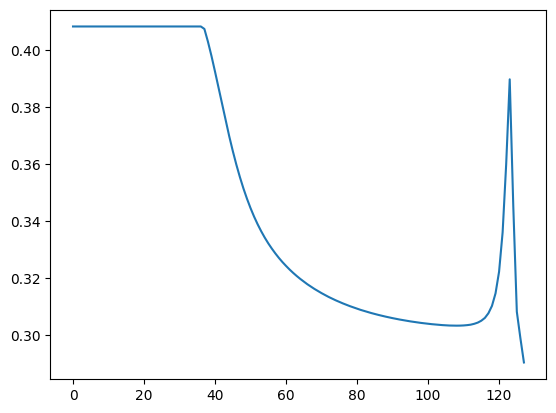

In [44]:
plt.plot(a)

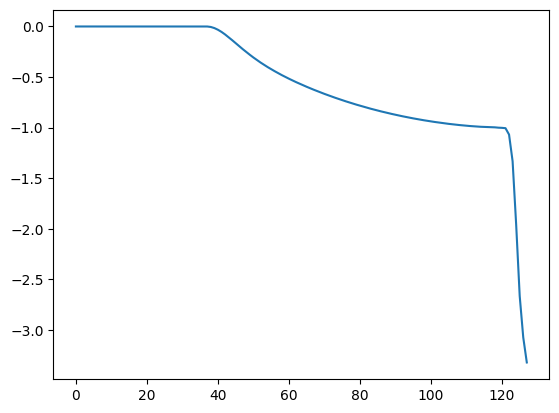

In [45]:
plt.plot(b)

  0%|          | 0/2000 [00:00<?, ?it/s]

accept rate: 0.0115


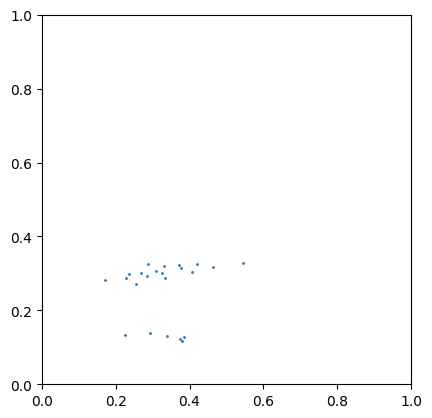

In [11]:
xs = importance_resample(observed_pixels=(60,80,124), sample_budget=2000, source_sampler='sobol', rejection_sampler='golden')
def plot_samples(xs):
    plt.scatter(xs[:,0], xs[:,2], s=1)
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()
plot_samples(xs)

In [20]:
# view recommendation

def adaptive_importance_resample(observed_pixels, source_sampler='sobol', rejection_sampler='golden'):
    initial_sample_budget = 300
    maximal_sample_budget = 10000
    target_ess = 500
    min_ess = 100
    max_ess = 2000
    # sample with initial budget
    samples = importance_resample(observed_pixels, initial_sample_budget, source_sampler, rejection_sampler)
    acc = len(samples) / initial_sample_budget
    if len(samples) < min_ess or len(samples) > max_ess:
        print("resampling with adjusted budget...")
        new_budget = min(int(target_ess / max(acc, 1e-6)), maximal_sample_budget)
        samples = importance_resample(observed_pixels, new_budget, source_sampler, rejection_sampler)
    return samples

pixel_list = list(range(37, 128))

def to_tuple(px):
    if isinstance(px, tuple):
        return px
    return (px,)

def view_recommend(observed_pixels):
    print("sampling parameter...")
    posterior_samples = adaptive_importance_resample(observed_pixels)
    print("number of parameter samples:", len(posterior_samples))
#     plot_samples(posterior_samples)
    print("rendering pixels using sampled parameters...")
    Is = torch.vstack([image(theta) for theta in tqdm(posterior_samples)])
    Ivar = Is.var(axis=0)
    added_posterior_variance = [posterior_variance(tuple(set((*to_tuple(observed_pixels), new_view)))).norm().sqrt().item() for new_view in range(128)]
    
    # Create a figure and a primary axis
    fig, ax1 = plt.subplots()

    # Plot the first line graph on the primary y-axis
    color = 'tab:red'
    ax1.set_xlabel('X')
    ax1.set_ylabel('variance of view radiance under current distribution', color=color)
    ax1.plot(Ivar.cpu(), color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_yscale('log')

        
    for x in to_tuple(observed_pixels):
        ax1.axvline(x, color='gray', linestyle='--', label='Reference Lines', alpha=0.7)


    # Create a secondary y-axis
    ax2 = ax1.twinx()

    # Plot the second line graph on the secondary y-axis
    color = 'tab:blue'
    ax2.set_ylabel('variance of distribution after adding the view', color=color)
    ax2.plot(added_posterior_variance, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # Display the plot
    plt.title("Two Line Graphs with Independent Y-Axis")
    plt.show()


sampling parameter...


  0%|          | 0/300 [00:00<?, ?it/s]

accept rate: 0.21333333333333335
resampling with adjusted budget...


  0%|          | 0/2343 [00:00<?, ?it/s]

accept rate: 0.22407170294494239
number of parameter samples: 525
rendering pixels using sampled parameters...


  0%|          | 0/525 [00:00<?, ?it/s]

torch.Size([129])


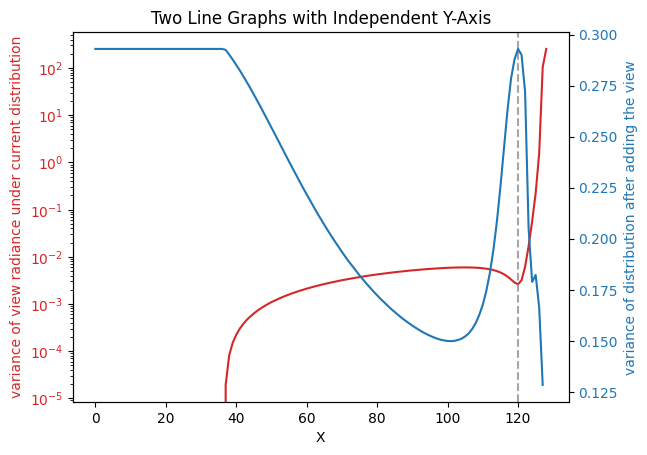

In [14]:
view_recommend(120)

sampling parameter...


  0%|          | 0/300 [00:00<?, ?it/s]

accept rate: 1.0
number of parameter samples: 300
rendering pixels using sampled parameters...


  0%|          | 0/300 [00:00<?, ?it/s]

torch.Size([129])


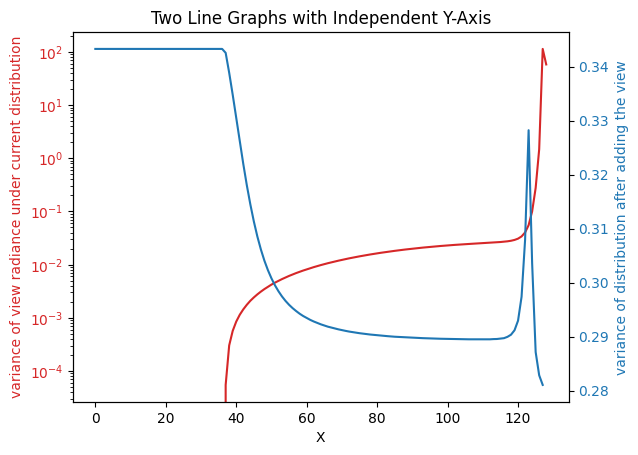

In [21]:
view_recommend(())

sampling parameter...


  0%|          | 0/300 [00:00<?, ?it/s]

accept rate: 0.22666666666666666
resampling with adjusted budget...


  0%|          | 0/2205 [00:00<?, ?it/s]

accept rate: 0.22040816326530613
number of parameter samples: 486


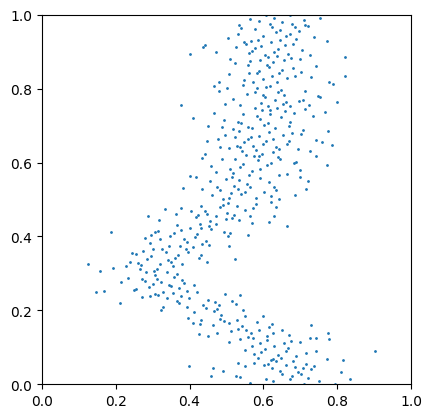

rendering pixels using sampled parameters...


  0%|          | 0/486 [00:00<?, ?it/s]

torch.Size([129])


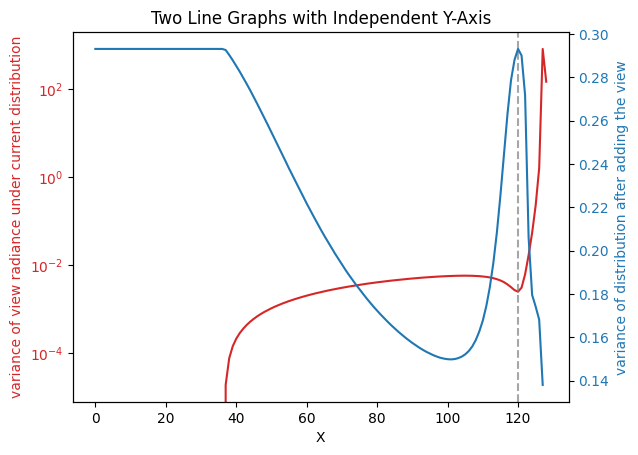

In [46]:
observed_pixels = 120
print("sampling parameter...")
posterior_samples = adaptive_importance_resample(observed_pixels)
print("number of parameter samples:", len(posterior_samples))
plot_samples(posterior_samples)
print("rendering pixels using sampled parameters...")
Is = torch.vstack([image(theta) for theta in tqdm(posterior_samples)])
Ivar = Is.var(axis=0)
print(Ivar.shape)
added_posterior_variance = [posterior_variance(tuple(set((*to_tuple(observed_pixels), new_view)))).norm().sqrt().item() for new_view in range(128)]

# Create a figure and a primary axis
fig, ax1 = plt.subplots()

# Plot the first line graph on the primary y-axis
color = 'tab:red'
ax1.set_xlabel('X')
ax1.set_ylabel('variance of view radiance under current distribution', color=color)
ax1.plot(Ivar.cpu(), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

ax1.axvline(observed_pixels, color='gray', linestyle='--', label='Reference Lines', alpha=0.7)


# Create a secondary y-axis
ax2 = ax1.twinx()

# Plot the second line graph on the secondary y-axis
color = 'tab:blue'
ax2.set_ylabel('variance of distribution after adding the view', color=color)
ax2.plot(added_posterior_variance, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Display the plot
plt.title("Two Line Graphs with Independent Y-Axis")
plt.show()


# plt.plot(Ivar.cpu().numpy())
# plt.yscale('log')

sampling parameter...


  0%|          | 0/300 [00:00<?, ?it/s]

accept rate: 0.23333333333333334
resampling with adjusted budget...


  0%|          | 0/2142 [00:00<?, ?it/s]

accept rate: 0.23062558356676005
number of parameter samples: 494


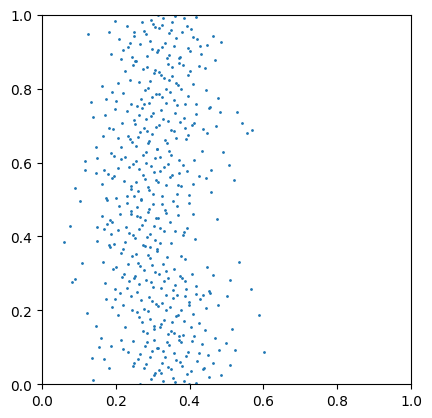

rendering pixels using sampled parameters...


  0%|          | 0/494 [00:00<?, ?it/s]

torch.Size([129])


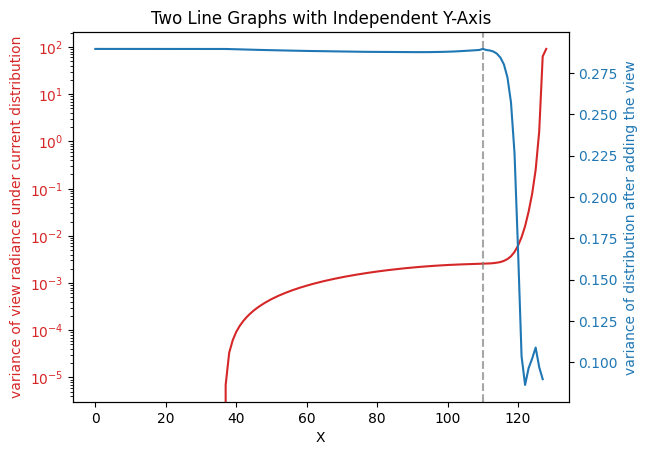

In [45]:
observed_pixels = 110
print("sampling parameter...")
posterior_samples = adaptive_importance_resample(observed_pixels)
print("number of parameter samples:", len(posterior_samples))
plot_samples(posterior_samples)
print("rendering pixels using sampled parameters...")
Is = torch.vstack([image(theta) for theta in tqdm(posterior_samples)])
Ivar = Is.var(axis=0)
print(Ivar.shape)
added_posterior_variance = [posterior_variance(tuple(set((*to_tuple(observed_pixels), new_view)))).norm().sqrt().item() for new_view in range(128)]

# Create a figure and a primary axis
fig, ax1 = plt.subplots()

# Plot the first line graph on the primary y-axis
color = 'tab:red'
ax1.set_xlabel('X')
ax1.set_ylabel('variance of view radiance under current distribution', color=color)
ax1.plot(Ivar.cpu(), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

ax1.axvline(observed_pixels, color='gray', linestyle='--', label='Reference Lines', alpha=0.7)


# Create a secondary y-axis
ax2 = ax1.twinx()

# Plot the second line graph on the secondary y-axis
color = 'tab:blue'
ax2.set_ylabel('variance of distribution after adding the view', color=color)
ax2.plot(added_posterior_variance, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Display the plot
plt.title("Two Line Graphs with Independent Y-Axis")
plt.show()


# plt.plot(Ivar.cpu().numpy())
# plt.yscale('log')

sampling parameter...


  0%|          | 0/300 [00:00<?, ?it/s]

accept rate: 0.0033333333333333335
resampling with adjusted budget...


  0%|          | 0/10000 [00:00<?, ?it/s]

accept rate: 0.0069
number of parameter samples: 69


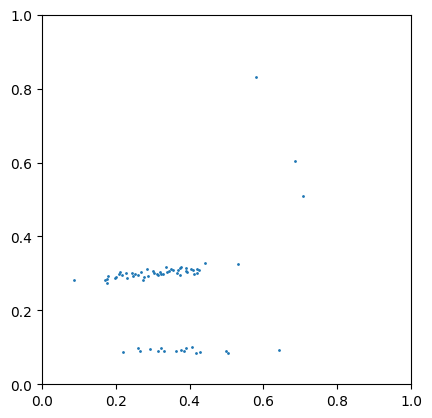

rendering pixels using sampled parameters...


  0%|          | 0/69 [00:00<?, ?it/s]

torch.Size([129])


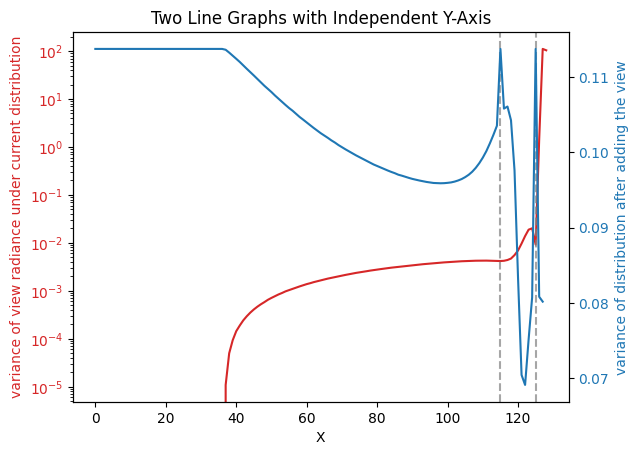

In [49]:
observed_pixels = 115, 125
print("sampling parameter...")
posterior_samples = adaptive_importance_resample(observed_pixels)
print("number of parameter samples:", len(posterior_samples))
plot_samples(posterior_samples)
print("rendering pixels using sampled parameters...")
Is = torch.vstack([image(theta) for theta in tqdm(posterior_samples)])
Ivar = Is.var(axis=0)
print(Ivar.shape)
added_posterior_variance = [posterior_variance(tuple(set((*to_tuple(observed_pixels), new_view)))).norm().sqrt().item() for new_view in range(128)]


# Create a figure and a primary axis
fig, ax1 = plt.subplots()

# Plot the first line graph on the primary y-axis
color = 'tab:red'
ax1.set_xlabel('X')
ax1.set_ylabel('variance of view radiance under current distribution', color=color)
ax1.plot(Ivar.cpu(), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

for x in to_tuple(observed_pixels):
    ax1.axvline(x, color='gray', linestyle='--', label='Reference Lines', alpha=0.7)

# Create a secondary y-axis
ax2 = ax1.twinx()

# Plot the second line graph on the secondary y-axis
color = 'tab:blue'
ax2.set_ylabel('variance of distribution after adding the view', color=color)
ax2.plot(added_posterior_variance, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Display the plot
plt.title("Two Line Graphs with Independent Y-Axis")
plt.show()


# plt.plot(Ivar.cpu().numpy())
# plt.yscale('log')

sampling parameter...


  0%|          | 0/300 [00:00<?, ?it/s]

accept rate: 0.37333333333333335
number of parameter samples: 112


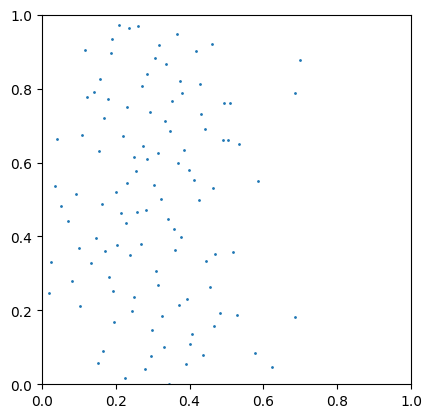

rendering pixels using sampled parameters...


  0%|          | 0/112 [00:00<?, ?it/s]

torch.Size([129])


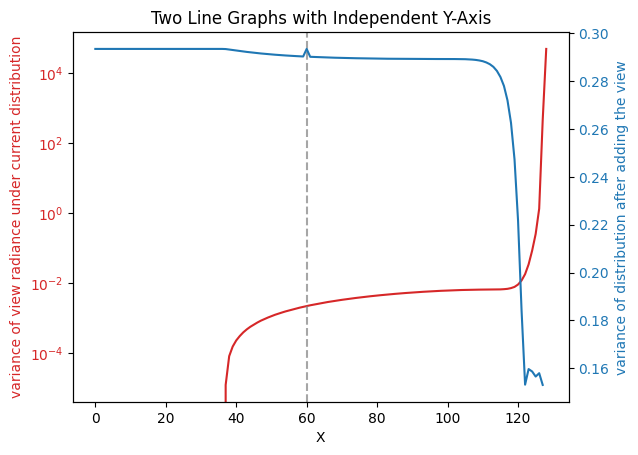

In [50]:
observed_pixels = 60
print("sampling parameter...")
posterior_samples = adaptive_importance_resample(observed_pixels)
print("number of parameter samples:", len(posterior_samples))
plot_samples(posterior_samples)
print("rendering pixels using sampled parameters...")
Is = torch.vstack([image(theta) for theta in tqdm(posterior_samples)])
Ivar = Is.var(axis=0)
print(Ivar.shape)
added_posterior_variance = [posterior_variance(tuple(set((*to_tuple(observed_pixels), new_view)))).norm().sqrt().item() for new_view in range(128)]


# Create a figure and a primary axis
fig, ax1 = plt.subplots()

# Plot the first line graph on the primary y-axis
color = 'tab:red'
ax1.set_xlabel('X')
ax1.set_ylabel('variance of view radiance under current distribution', color=color)
ax1.plot(Ivar.cpu(), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

for x in to_tuple(observed_pixels):
    ax1.axvline(x, color='gray', linestyle='--', label='Reference Lines', alpha=0.7)

# Create a secondary y-axis
ax2 = ax1.twinx()

# Plot the second line graph on the secondary y-axis
color = 'tab:blue'
ax2.set_ylabel('variance of distribution after adding the view', color=color)
ax2.plot(added_posterior_variance, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Display the plot
plt.title("Two Line Graphs with Independent Y-Axis")
plt.show()


# plt.plot(Ivar.cpu().numpy())
# plt.yscale('log')

sampling parameter...


  0%|          | 0/300 [00:00<?, ?it/s]

accept rate: 0.25
resampling with adjusted budget...


  0%|          | 0/2000 [00:00<?, ?it/s]

accept rate: 0.2555
number of parameter samples: 511


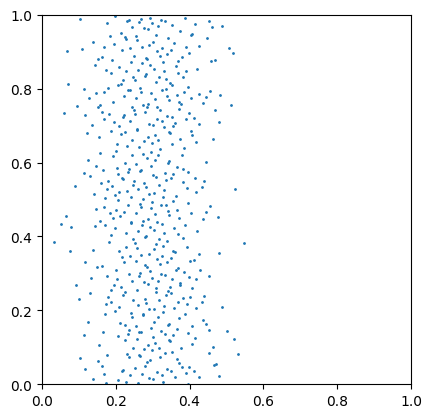

rendering pixels using sampled parameters...


  0%|          | 0/511 [00:00<?, ?it/s]

torch.Size([129])


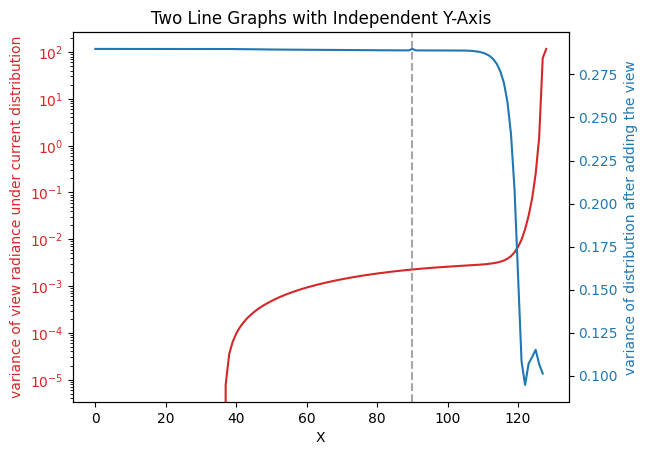

In [51]:
observed_pixels = 90
print("sampling parameter...")
posterior_samples = adaptive_importance_resample(observed_pixels)
print("number of parameter samples:", len(posterior_samples))
plot_samples(posterior_samples)
print("rendering pixels using sampled parameters...")
Is = torch.vstack([image(theta) for theta in tqdm(posterior_samples)])
Ivar = Is.var(axis=0)
print(Ivar.shape)
added_posterior_variance = [posterior_variance(tuple(set((*to_tuple(observed_pixels), new_view)))).norm().sqrt().item() for new_view in range(128)]


# Create a figure and a primary axis
fig, ax1 = plt.subplots()

# Plot the first line graph on the primary y-axis
color = 'tab:red'
ax1.set_xlabel('X')
ax1.set_ylabel('variance of view radiance under current distribution', color=color)
ax1.plot(Ivar.cpu(), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

for x in to_tuple(observed_pixels):
    ax1.axvline(x, color='gray', linestyle='--', label='Reference Lines', alpha=0.7)

# Create a secondary y-axis
ax2 = ax1.twinx()

# Plot the second line graph on the secondary y-axis
color = 'tab:blue'
ax2.set_ylabel('variance of distribution after adding the view', color=color)
ax2.plot(added_posterior_variance, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Display the plot
plt.title("Two Line Graphs with Independent Y-Axis")
plt.show()


# plt.plot(Ivar.cpu().numpy())
# plt.yscale('log')